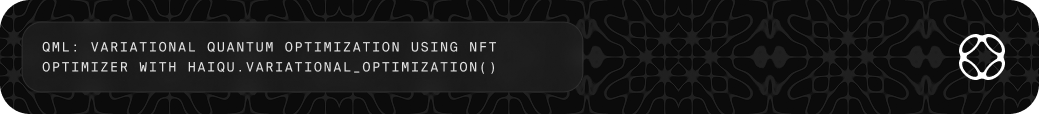

This notebook demonstrates how to use `haiqu.variational_optimization()` for variational quantum optimization using the [NFT (Nakanishi-Fujii-Todo) optimizer](https://arxiv.org/abs/1903.12166).

- Define a parameterized quantum circuit (ansatz) and an observable.
- Submit a job to the Haiqu API where the **NFT gradient-free optimizer** searches for an optimal solution.
- Retrieve **optimized parameters, minimum loss, and loss history**.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.variational_optimization()`

- **What does it do?** Submits a variational optimization job to the Haiqu API, using the [NFT](https://arxiv.org/abs/1903.12166) gradient-free optimizer to search for circuit parameters that minimize the expectation value of an observable.
- **How do I use it?** Create a `VariationalProblem` with your parameterized ansatz circuit and observable, then submit with `haiqu.variational_optimization()`. The function returns a job handle to track progress and retrieve results.
- **What are the options?**
  - `device_id` – choose backend by ID (simulators or real hardware).
  - `device` – alternatively, pass a device object directly.
  - `shots` – number of shots per circuit evaluation (default: 1000).
  - `initial_parameters` – starting parameter values. If not provided, parameters are initialized randomly.
  - `seed` – random seed for reproducible initial parameters (optional).
  - `optimizer_options` – NFT optimizer configuration (maxfev, maxiter, etc.).
  - `use_mitigation` – enable error mitigation (default: False). For deeper circuits, error mitigation might help improve results—try playing around with this option or turning on EM.
  - `use_session` – enable [IBM Qiskit Runtime Session](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/session) for execution (default: False). A session groups iterative calls to the quantum computer so that subsequent jobs are prioritized by the scheduler, reducing wall-clock time. Note: sessions may consume more QPU time overall despite shorter wait times. Only available on real hardware backends, not simulators.
  - `use_packing` – enable circuit packing for efficient device utilization (default: False). **Experimental** — packing replicates circuits on unused device qubits to run multiple copies in parallel, which may increase errors for deeper circuits.
  - `pack_size` – number of circuit copies to pack onto the device (must be >= 2). Only valid when `use_packing=True`. If `None` (default), the backend packs into at most 2/3 of the device qubits.
- **Which options do you recommend?** Start with `aer_simulator` for quick results. To improve optimization:
  - `shots` (default 1000) – increase for more accurate expectation value estimates.
  - `maxfev` (default 1024) – increase to allow more circuit evaluations for better convergence.
  - `seed` – set for reproducible results across runs.
  - `use_session` – can reduce wall-clock time on real QPU hardware by grouping iterative calls into a single session. Note that sessions may consume more QPU time overall despite the shorter wait. Only available on real hardware backends, not simulators.
  - `use_packing` / `pack_size` – try `use_packing=True, pack_size=2` for cost savings on QPU runs (e.g., a 4-qubit circuit with 1000 shots runs two copies with 500 shots each, yielding 1000 results while only paying for 500 shot executions).

## Initialize and define the problem

Import the necessary libraries, initialize the Haiqu SDK, and create a 3-qubit variational problem using the EfficientSU2 ansatz.

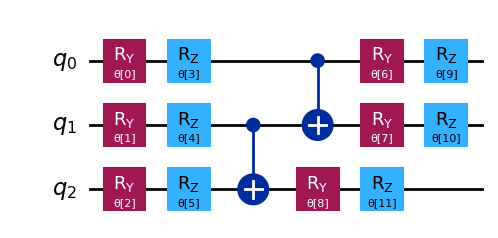

In [1]:
import warnings
warnings.filterwarnings('ignore')

from haiqu.sdk import haiqu
from haiqu.sdk.qml import VariationalProblem, NFTOptimizerOptions
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp

haiqu.login()
haiqu.init("Variational Optimization Tutorial")

# Create a 3-qubit EfficientSU2 ansatz
num_qubits = 3
ansatz = EfficientSU2(num_qubits=num_qubits, reps=1)

# Define the observable to minimize (ZZZ)
observable = SparsePauliOp.from_list([("Z" * num_qubits, 1.0)])

# Create the variational problem
problem = VariationalProblem(ansatz, observable)

ansatz.decompose().draw("mpl")

## Submit the variational optimization job

The NFT optimizer will iteratively update parameters to minimize the observable expectation value.

In [2]:
optimizer_options = NFTOptimizerOptions(maxiter=5)

job = haiqu.variational_optimization(
    problem=problem,
    device_id="aer_simulator",
    shots=1000,
    seed=42,
    optimizer_options=optimizer_options,
    use_session=False,  # Set True for real QPU hardware to reduce queuing time (not available on simulators)
    use_packing=False,  # Try use_packing=True with pack_size=2 for cost savings on QPU
    # pack_size=2,
)

result = job.result()

## Analyze the results

Visualize the optimization convergence by plotting the loss history.

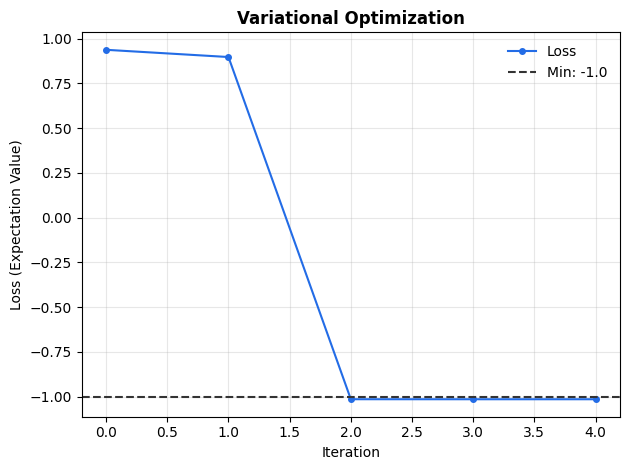

In [3]:
import matplotlib.pyplot as plt

plt.figure(dpi=100)
plt.plot(result.loss_history, 'o-', color='#236CE6', ms=4, lw=1.5, markevery=0.05, label='Loss')
plt.axhline(-1, color='#333333', ls='--', label=f'Min: {-1.0}')

plt.title("Variational Optimization", weight='bold')
plt.xlabel("Iteration")
plt.ylabel("Loss (Expectation Value)")
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **Good to Know:** The [NFT optimizer](https://arxiv.org/abs/1903.12166) is gradient-free, making it robust against noisy quantum hardware. Each parameter is updated independently, requiring only 2-3 circuit evaluations per parameter update. For problems with large number of parameters, consider increasing `maxfev` to allow more evaluations for convergence.
>
>
>     **Important:** Parameters must be independent in the pre-transpilation circuit. Each parameter must appear in exactly one gate (no reusing the same parameter across multiple gates).
>
>
>     **Circuit Packing (Experimental):** Setting `use_packing=True` replicates your circuit on unused device qubits to run multiple copies in parallel — for example, a 4-qubit circuit with `pack_size=2` and 1000 shots runs two copies with 500 shots each, yielding 1000 results while only paying for 500 shot executions on the QPU. Try starting with `pack_size=2`. Note that packing may increase errors for deeper circuits.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

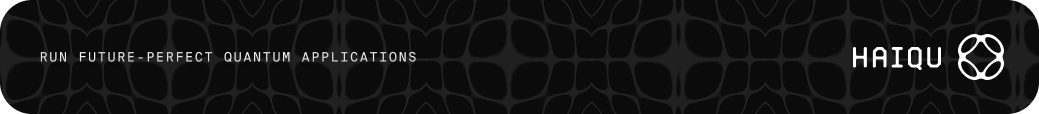